In [8]:
%load_ext kedro.ipython

The kedro.ipython extension is already loaded. To reload it, use:
  %reload_ext kedro.ipython


In [9]:
!uv pip install --upgrade seaborn matplotlib

Using Python 3.12.12 environment at: /home/xxxdkgxxx/PycharmProjects/WSI-reg-class/wsi-cls/.venv
Resolved 13 packages in 301ms                                        
Audited 13 packages in 0.13ms


In [10]:
df = catalog.load("ortodoncja")

df

[03/04/26 22:55:03] INFO     Loading data from ortodoncja (CSVDataset)...                      ]8;id=995635;file:///home/xxxdkgxxx/PycharmProjects/WSI-reg-class/wsi-cls/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py\data_catalog.py]8;;\:]8;id=992948;file:///home/xxxdkgxxx/PycharmProjects/WSI-reg-class/wsi-cls/.venv/lib/python3.12/site-packages/kedro/io/data_catalog.py#1048\1048]8;;\

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_Mn Ramus Angle,12_SNPog,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,...,116.585770,77.233907,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,horizontal
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,...,120.371230,79.480178,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,horizontal
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,...,117.981833,80.125853,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,horizontal
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,...,118.071540,82.430061,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,horizontal
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,...,128.441180,76.907972,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,35.178582,88.026303,67.291160,2.325724,124.614357,76.842483,76.751712,83.320475,6.472243,-6.568763,...,124.063284,78.847063,78.671476,83.623443,6.967580,-4.951967,1.412868,0.175587,20.030570,normal
442,34.299938,87.339586,65.735458,2.328455,123.087223,77.248174,75.250947,81.604217,5.806036,-6.353270,...,122.056916,77.897540,76.621034,82.268413,7.740249,-5.647379,1.538280,1.276505,17.196355,normal
443,30.186415,85.332030,63.742767,2.619851,116.289956,79.646663,77.716725,79.289320,3.550770,-1.572595,...,113.778421,79.943289,77.827477,79.583359,5.638938,-1.755881,1.463132,2.115812,19.865993,horizontal
444,43.308352,96.535111,71.936381,0.996169,136.078325,73.914911,74.199658,81.212461,2.141273,-7.012803,...,132.275846,75.637836,76.037974,83.270586,1.811463,-7.232613,1.512700,-0.400137,15.510283,normal


In [11]:
df["growth direction"].value_counts()


growth direction
normal        246
horizontal    184
vertical       16
Name: count, dtype: int64

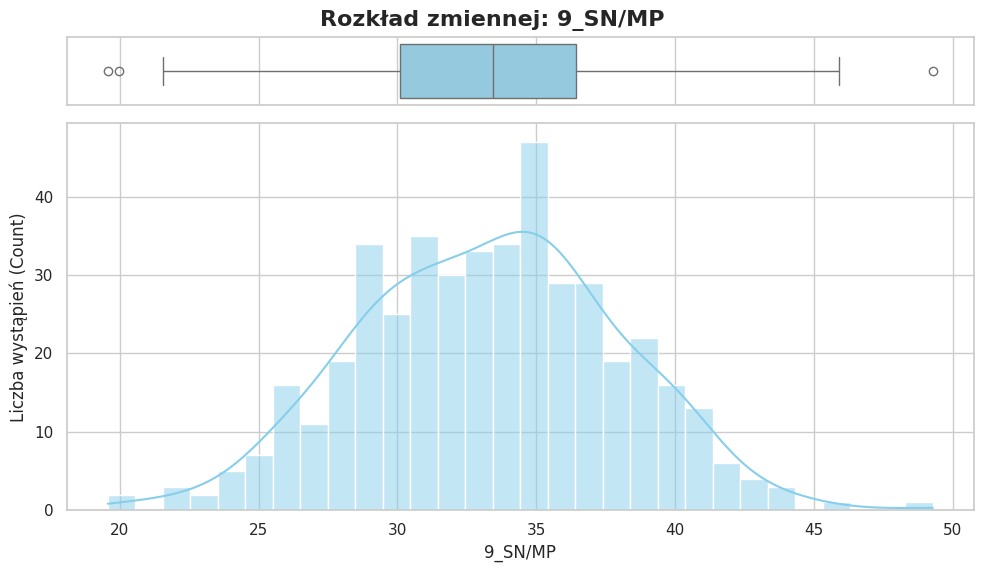

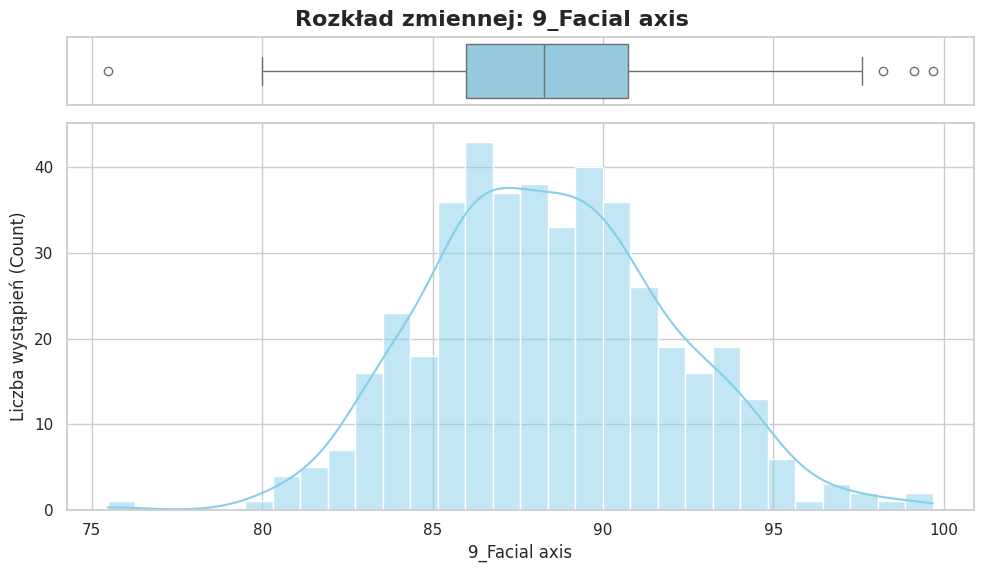

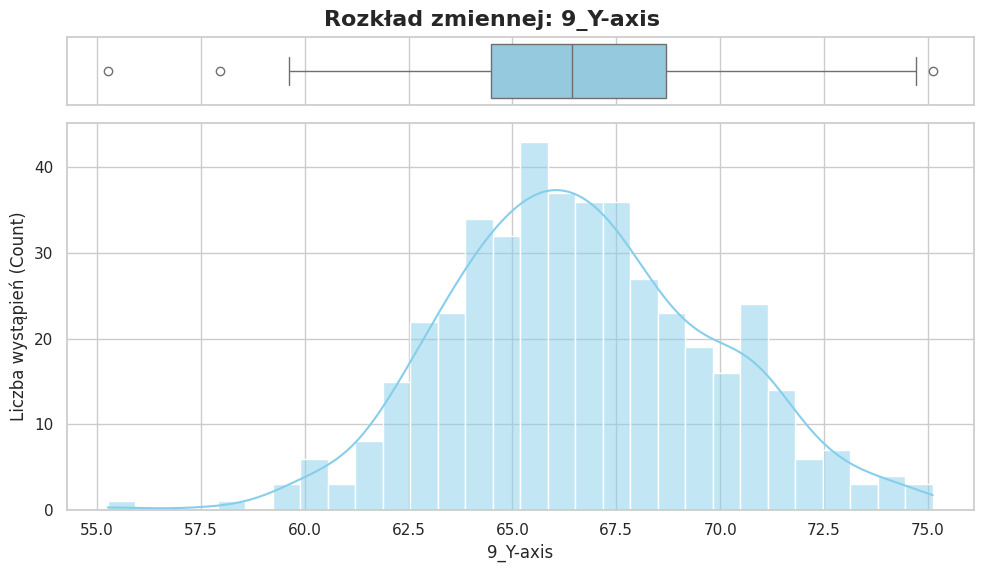

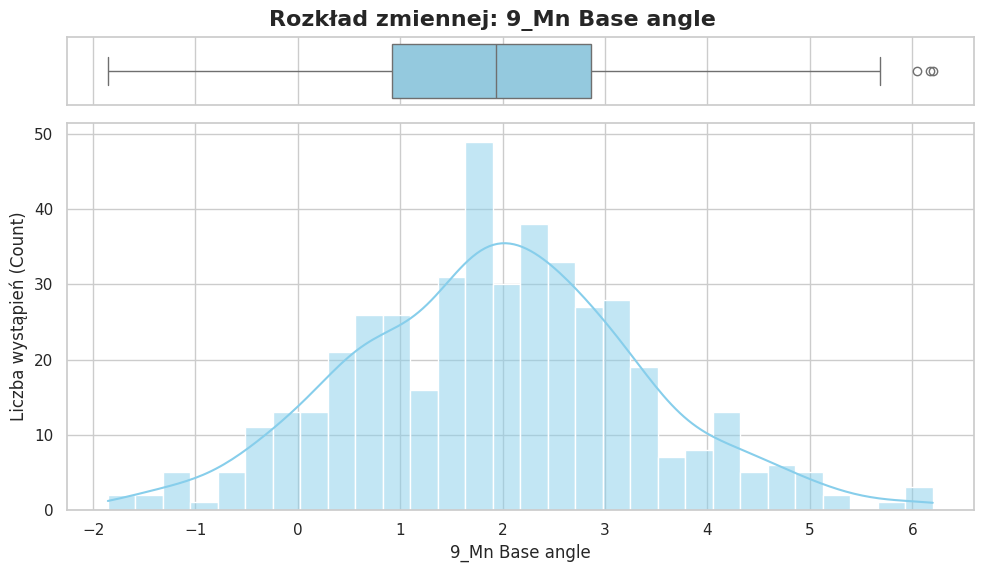

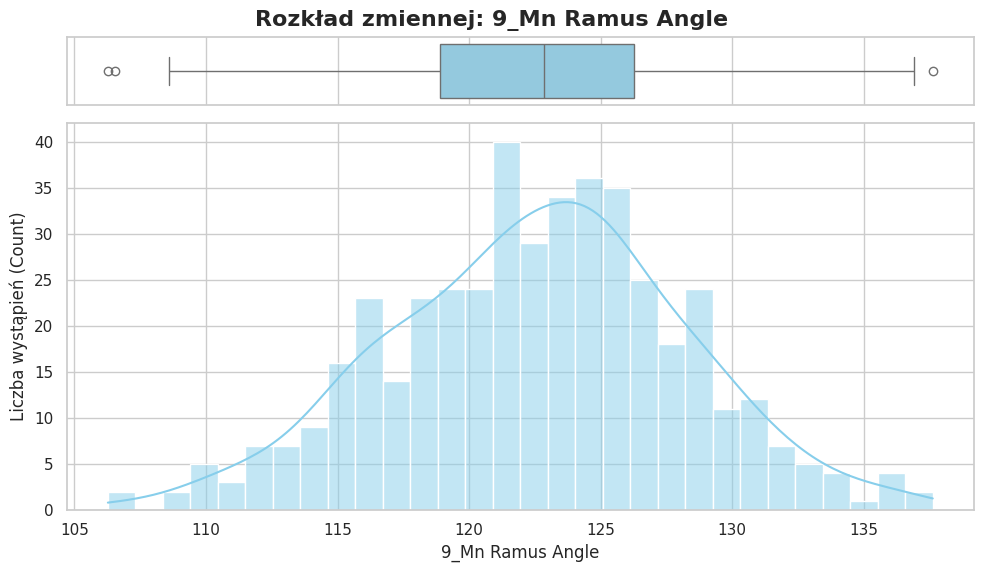

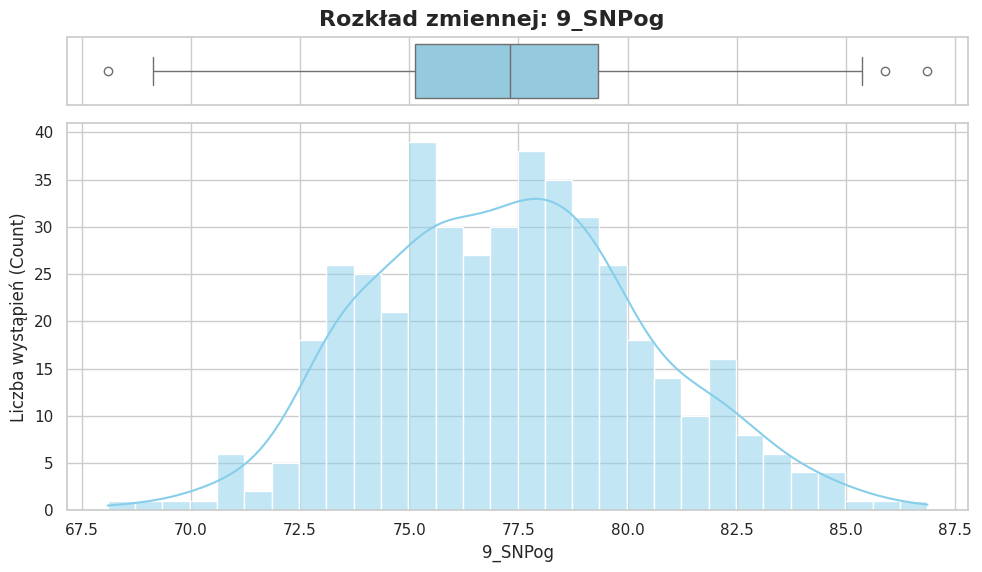

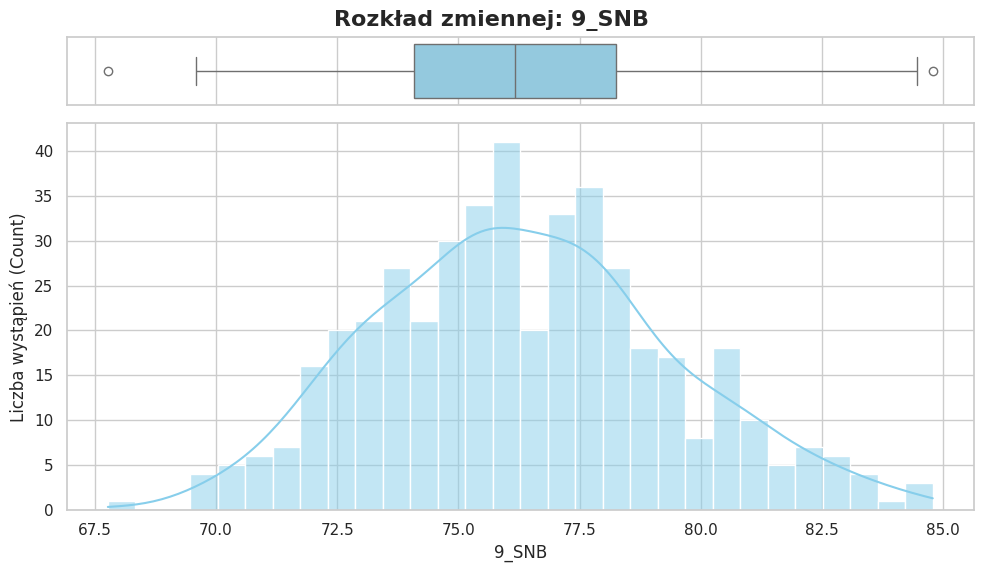

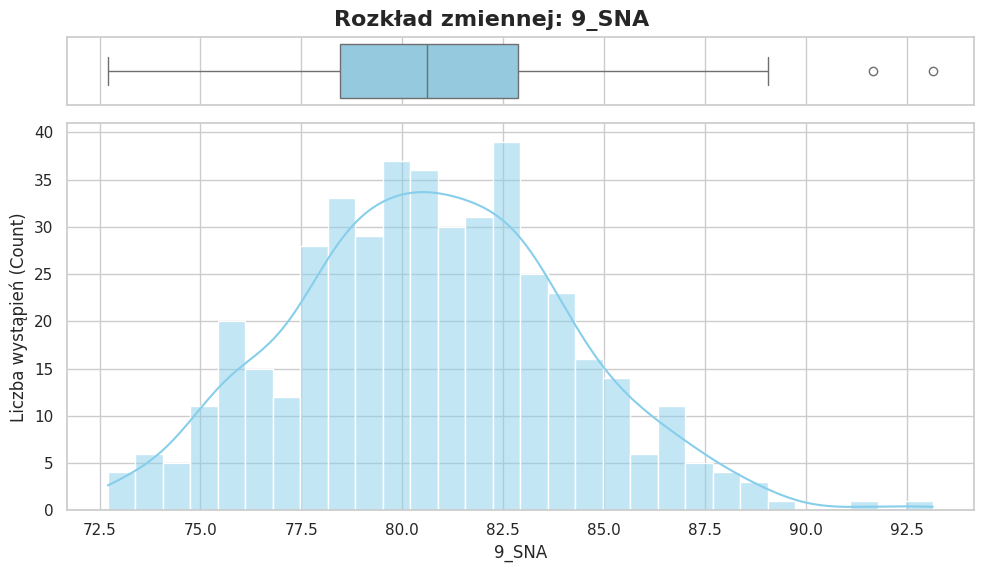

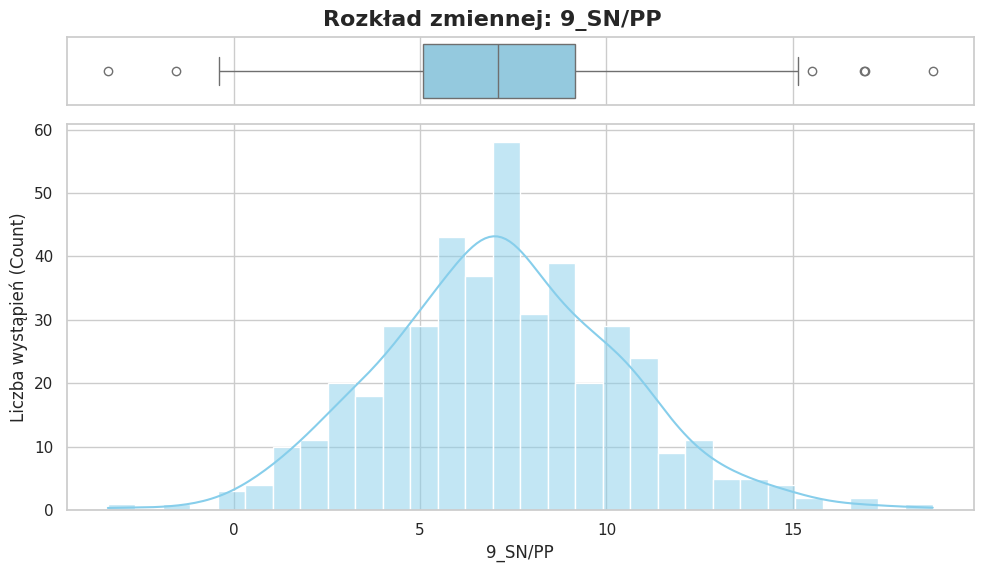

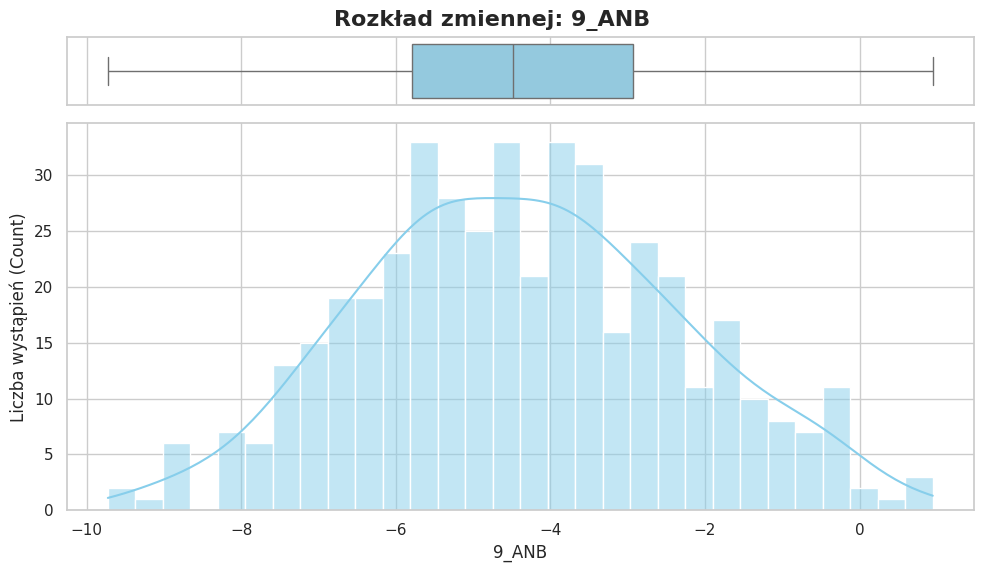

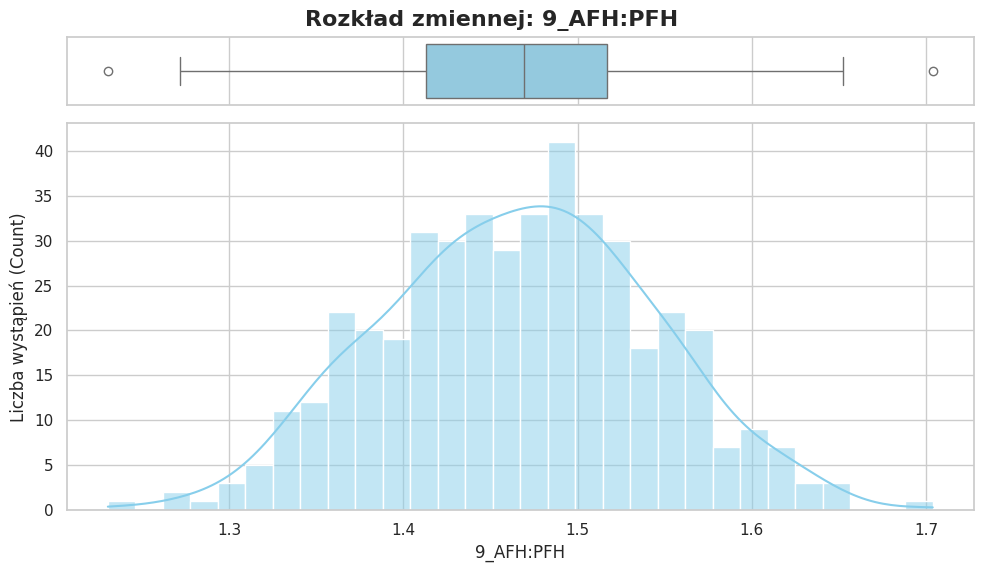

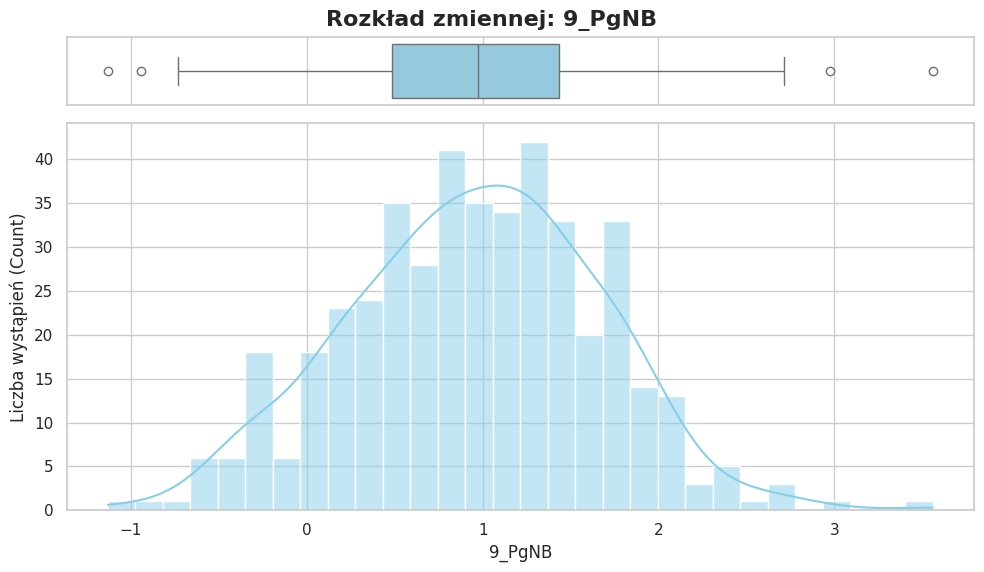

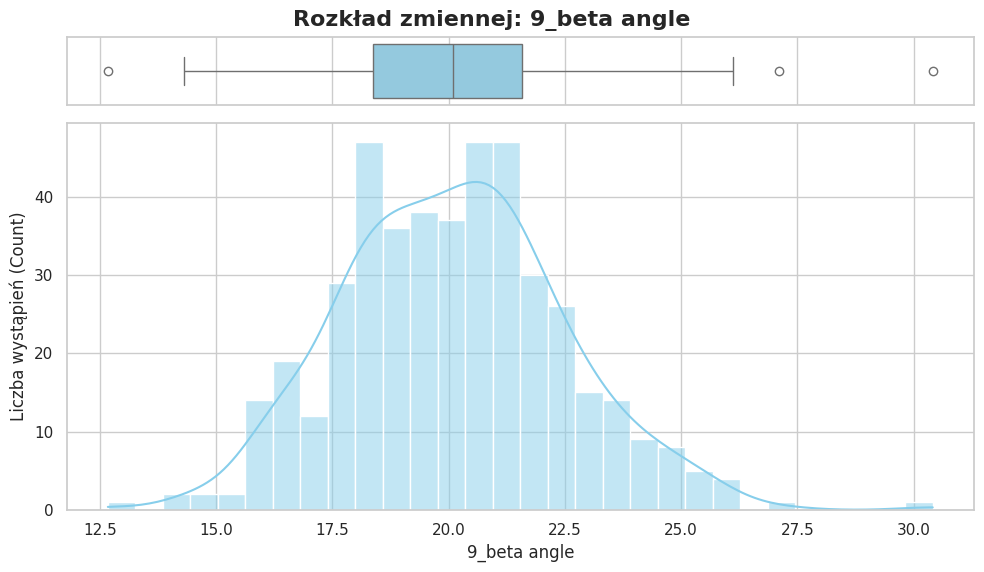

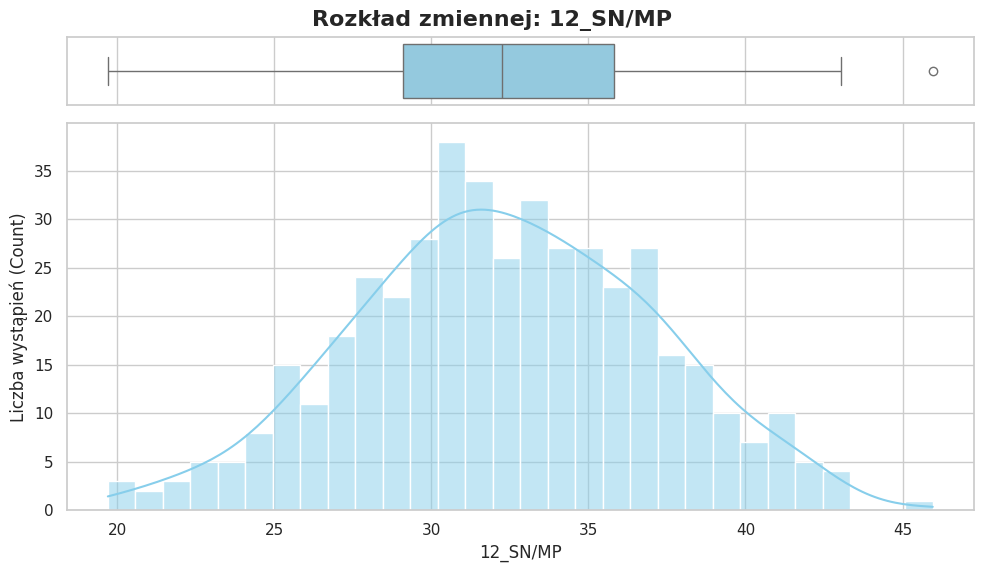

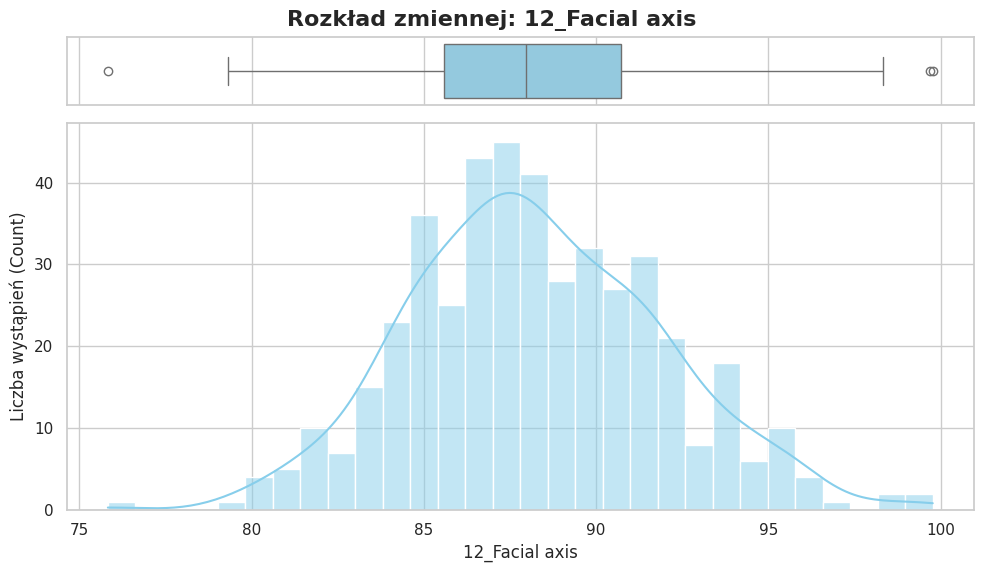

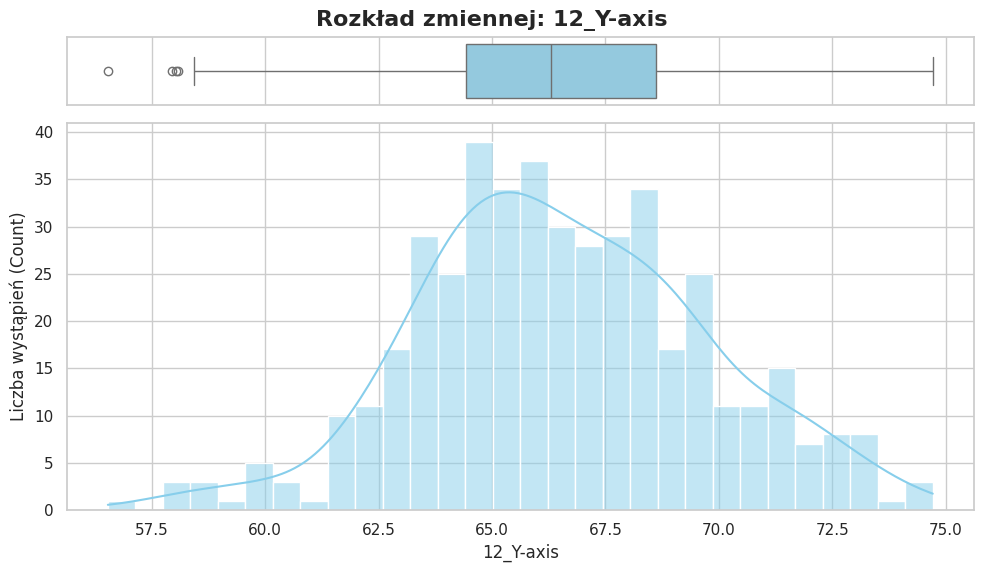

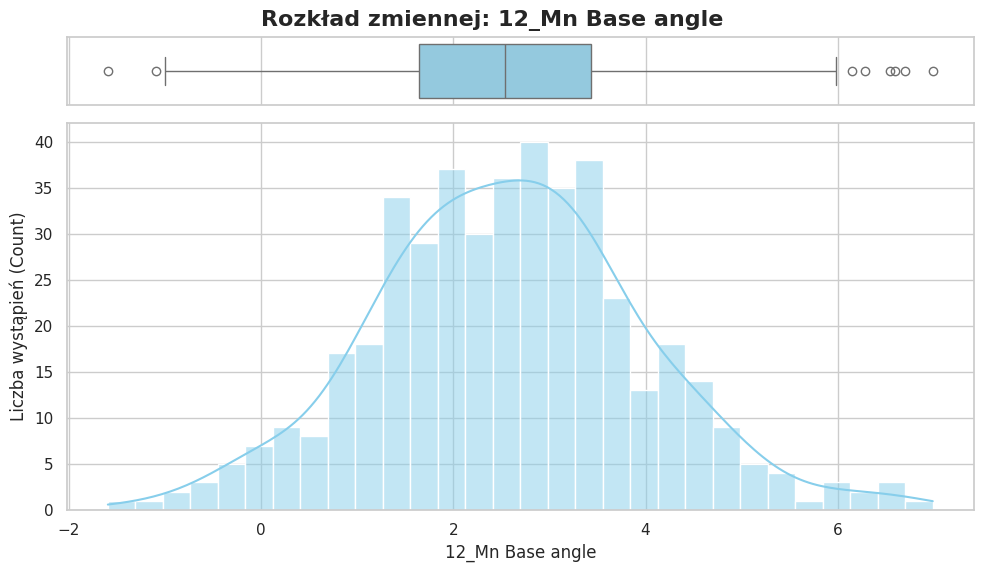

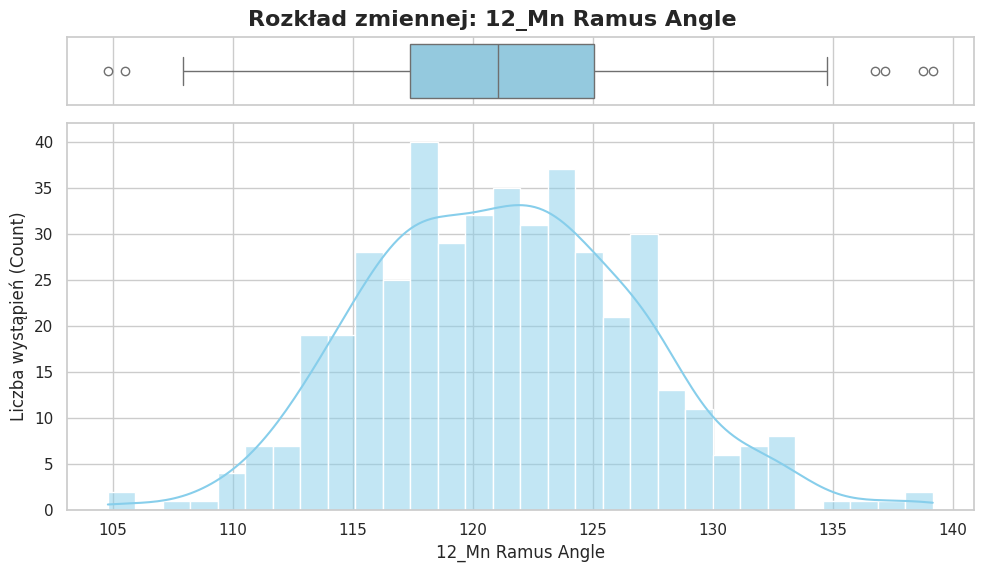

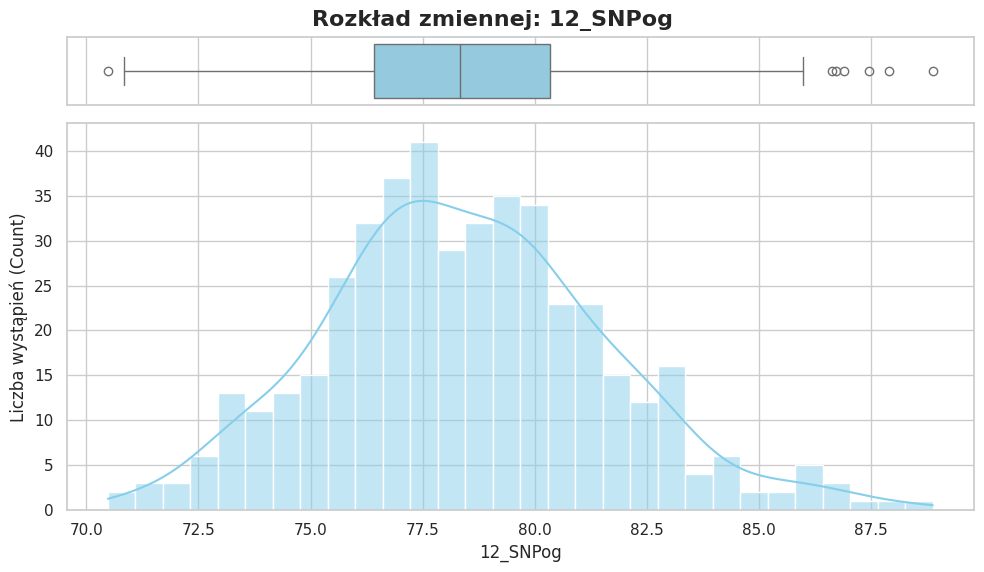

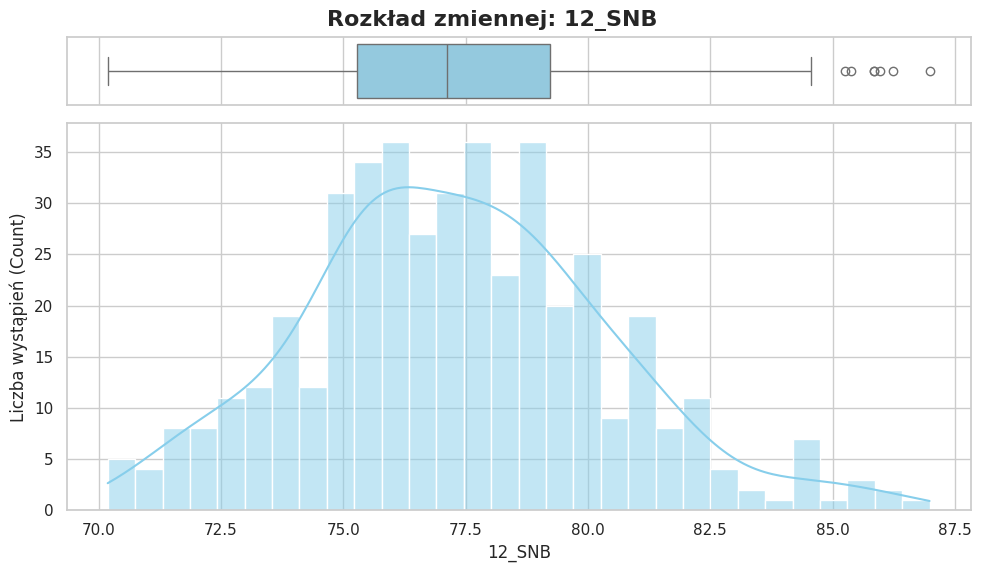

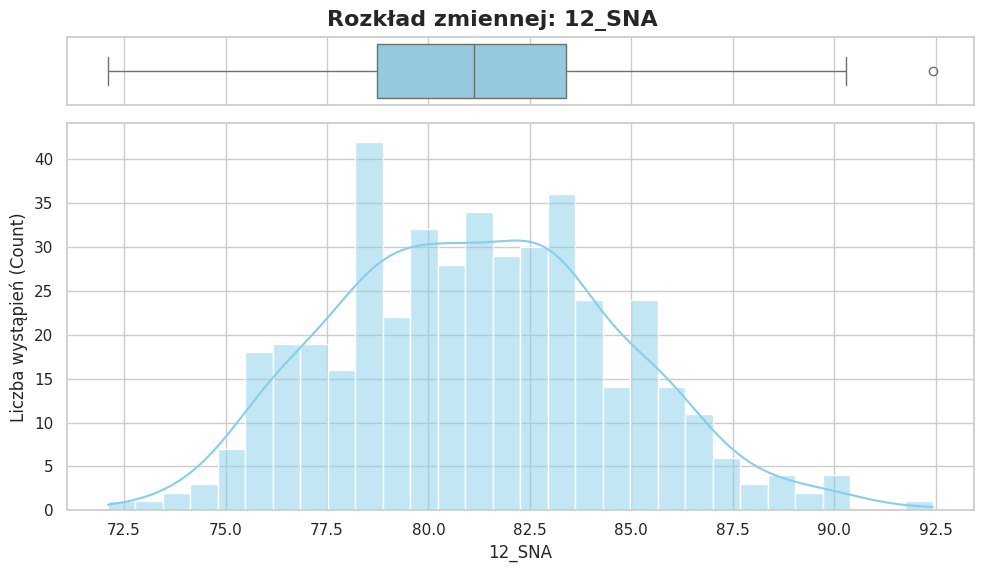

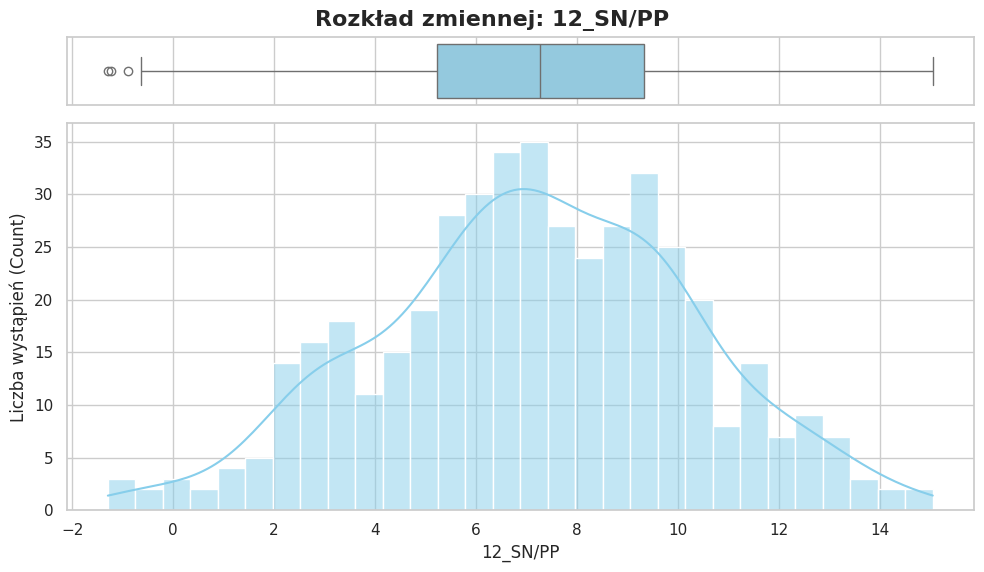

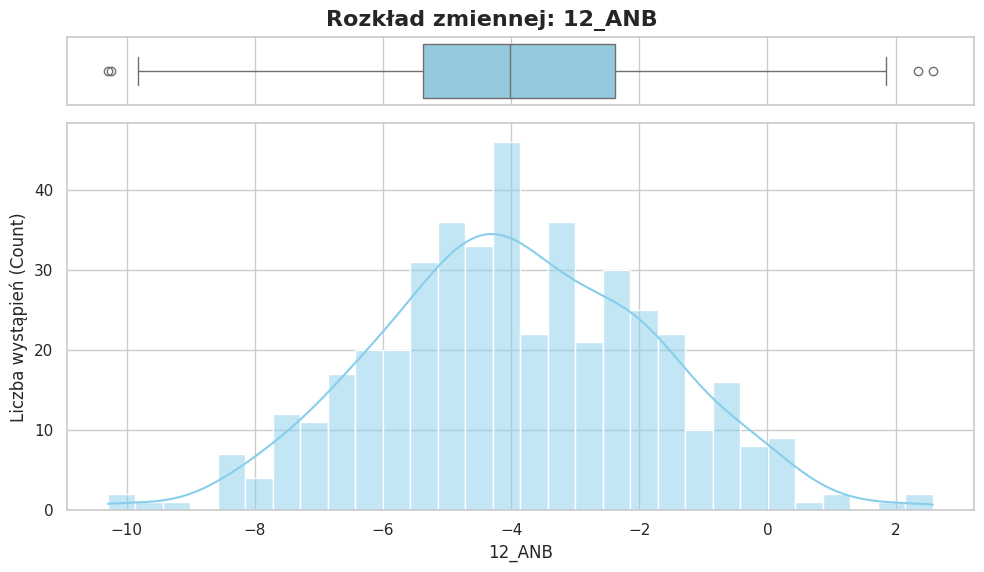

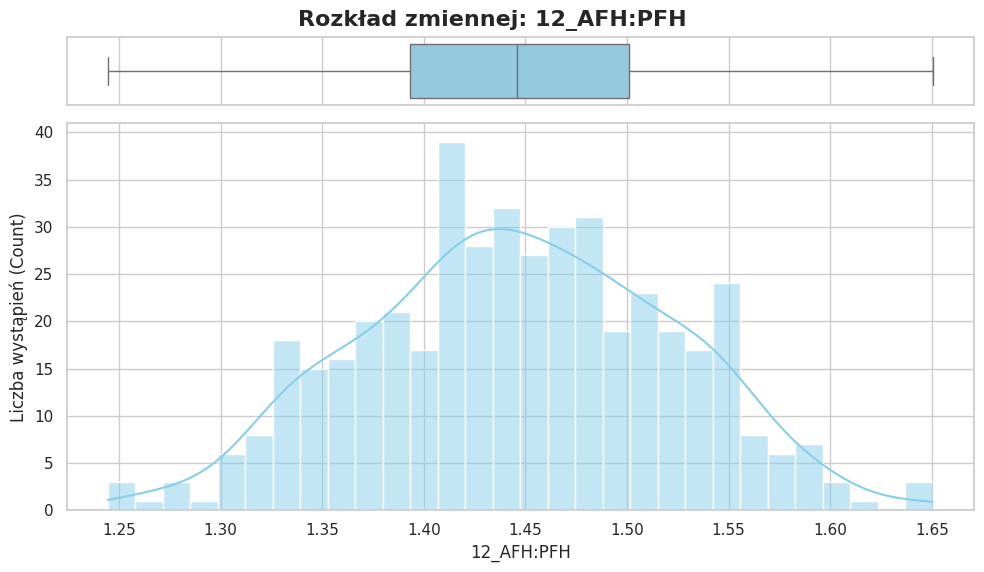

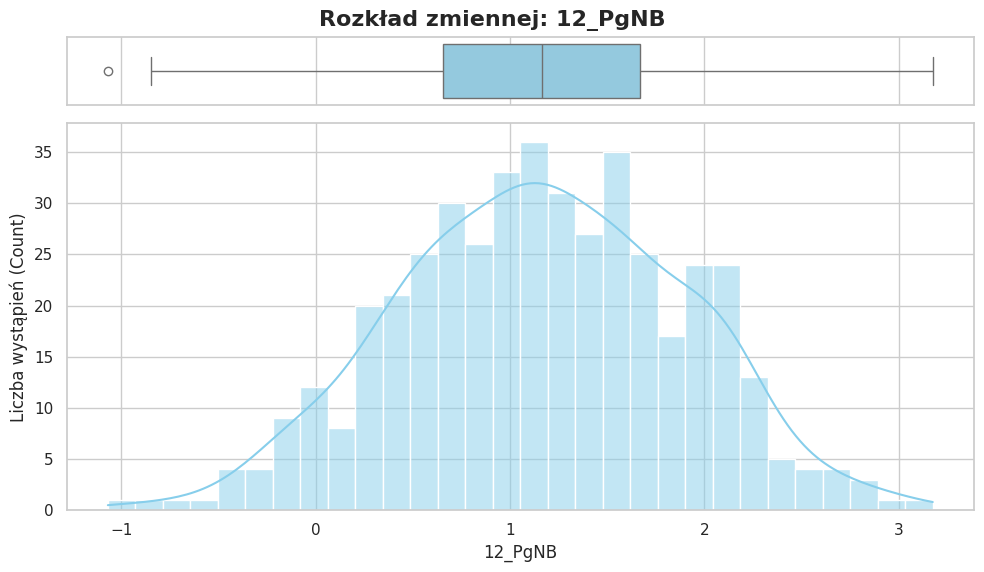

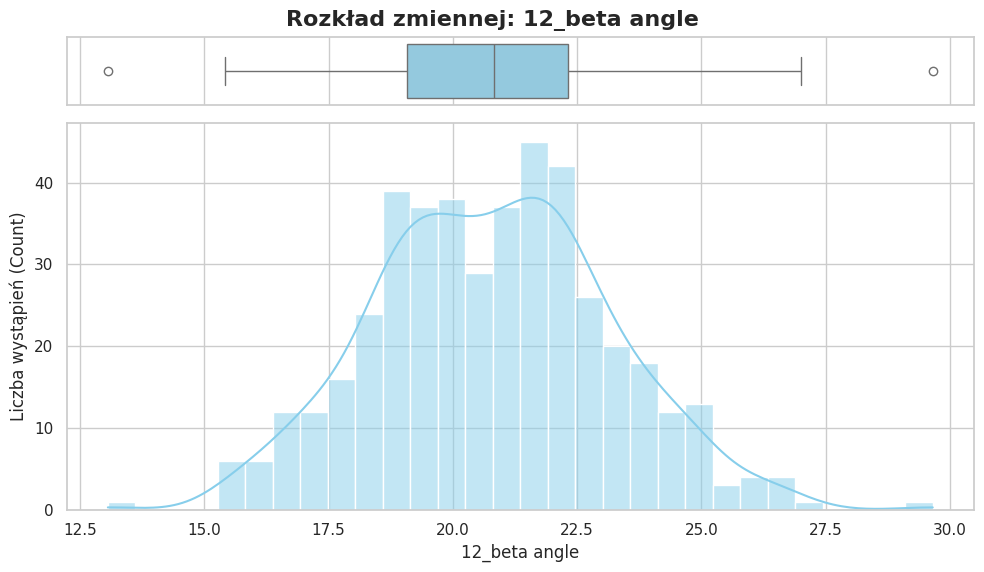

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

def plot_distributions(dataframe):
    numeric_cols = dataframe.select_dtypes(include=['number']).columns

    for col in numeric_cols:
        fig, (ax_box, ax_hist) = plt.subplots(
            2, 
            sharex=True, 
            gridspec_kw={"height_ratios": (.15, .85)}, 
            figsize=(10, 6)
        )
        
        sns.boxplot(x=dataframe[col], ax=ax_box, color="skyblue")
        ax_box.set(xlabel='')
        
        sns.histplot(data=dataframe, x=col, ax=ax_hist, kde=True, bins=30, color="skyblue")
        ax_hist.set(ylabel='Liczba wystąpień (Count)')
        
        plt.suptitle(f'Rozkład zmiennej: {col}', fontsize=16, fontweight='bold', y=0.95)
        
        plt.tight_layout()
        plt.show()

plot_distributions(df)

In [13]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, )
enc.set_output(transform='pandas')

enc.fit(df[["growth direction"]])

enc_df = enc.transform(df[["growth direction"]])

enc_df

df = pd.concat([df, enc_df], axis=1)

df = df.drop(columns="growth direction")

df


,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction_horizontal,growth direction_normal,growth direction_vertical
0,28.882655,87.411884,66.908260,0.415477,111.114850,75.585670,74.142998,80.118387,13.603083,-5.975389,...,76.042877,80.645978,10.223444,-4.603101,1.416613,1.191030,22.220111,1.0,0.0,0.0
1,35.410983,90.714247,67.379392,2.480978,123.868967,77.719090,75.980740,77.756093,6.041252,-1.775353,...,77.289118,83.189766,2.538123,-5.900647,1.500294,2.191060,18.056378,1.0,0.0,0.0
2,27.952347,90.827615,65.432107,2.277330,119.958531,78.909186,77.545863,81.804363,4.403767,-4.258501,...,78.238824,81.127838,4.228677,-2.889014,1.341424,1.887029,22.169193,1.0,0.0,0.0
3,25.138396,82.195544,59.619544,2.539409,118.323917,80.678309,78.714113,86.651762,1.864515,-7.937649,...,80.259569,88.624746,-0.890545,-8.365177,1.355916,2.170492,21.251448,1.0,0.0,0.0
4,33.761656,90.240915,65.960066,2.929263,126.728619,76.907767,76.334661,83.908674,14.651077,-7.574013,...,76.362007,83.320338,13.187977,-6.958331,1.459762,0.545964,18.528448,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,35.178582,88.026303,67.291160,2.325724,124.614357,76.842483,76.751712,83.320475,6.472243,-6.568763,...,78.671476,83.623443,6.967580,-4.951967,1.412868,0.175587,20.030570,0.0,1.0,0.0
442,34.299938,87.339586,65.735458,2.328455,123.087223,77.248174,75.250947,81.604217,5.806036,-6.353270,...,76.621034,82.268413,7.740249,-5.647379,1.538280,1.276505,17.196355,0.0,1.0,0.0
443,30.186415,85.332030,63.742767,2.619851,116.289956,79.646663,77.716725,79.289320,3.550770,-1.572595,...,77.827477,79.583359,5.638938,-1.755881,1.463132,2.115812,19.865993,1.0,0.0,0.0
444,43.308352,96.535111,71.936381,0.996169,136.078325,73.914911,74.199658,81.212461,2.141273,-7.012803,...,76.037974,83.270586,1.811463,-7.232613,1.512700,-0.400137,15.510283,0.0,1.0,0.0


In [14]:
df.corr(numeric_only=True)

,9_SN/MP,9_Facial axis,9_Y-axis,9_Mn Base angle,9_Mn Ramus Angle,9_SNPog,9_SNB,9_SNA,9_SN/PP,9_ANB,...,12_SNB,12_SNA,12_SN/PP,12_ANB,12_AFH:PFH,12_PgNB,12_beta angle,growth direction_horizontal,growth direction_normal,growth direction_vertical
9_SN/MP,1.000000,0.670009,0.786822,-0.055448,0.614780,-0.705692,-0.635962,-0.457572,0.401536,-0.184363,...,-0.556176,-0.425240,0.396454,-0.116151,0.862119,-0.332258,-0.685871,-0.472880,0.359874,0.289384
9_Facial axis,0.670009,1.000000,0.827440,-0.087434,0.179197,-0.585322,-0.509748,-0.268965,0.315496,-0.309550,...,-0.474154,-0.285484,0.283923,-0.222367,0.494348,-0.310750,-0.250289,-0.335350,0.268581,0.169465
9_Y-axis,0.786822,0.827440,1.000000,-0.075763,0.196867,-0.824868,-0.768684,-0.527675,0.463147,-0.264838,...,-0.691987,-0.487889,0.422546,-0.210207,0.630310,-0.279962,-0.251274,-0.372739,0.310680,0.155856
9_Mn Base angle,-0.055448,-0.087434,-0.075763,1.000000,-0.035201,0.083623,0.040858,0.002971,-0.047212,0.055559,...,0.037018,0.007763,-0.023063,0.040527,-0.005507,0.197653,0.018922,0.072226,-0.078463,0.018634
9_Mn Ramus Angle,0.614780,0.179197,0.196867,-0.035201,1.000000,-0.232801,-0.172684,-0.107538,0.094791,-0.077697,...,-0.127463,-0.088558,0.139590,-0.040992,0.488072,-0.270033,-0.774039,-0.317427,0.204431,0.293570
9_SNPog,-0.705692,-0.585322,-0.824868,0.083623,-0.232801,1.000000,0.973981,0.736493,-0.533554,0.223270,...,0.852842,0.652527,-0.468938,0.177009,-0.635397,0.178636,0.256157,0.296841,-0.251271,-0.113819
9_SNB,-0.635962,-0.509748,-0.768684,0.040858,-0.172684,0.973981,1.000000,0.801974,-0.536767,0.153462,...,0.879907,0.716031,-0.459767,0.114172,-0.601737,-0.002207,0.213727,0.185465,-0.153871,-0.079462
9_SNA,-0.457572,-0.268965,-0.527675,0.002971,-0.107538,0.736493,0.801974,1.000000,-0.424898,-0.467211,...,0.705370,0.855391,-0.344829,-0.358372,-0.476756,-0.190756,0.180710,0.040116,-0.004781,-0.093405
9_SN/PP,0.401536,0.315496,0.463147,-0.047212,0.094791,-0.533554,-0.536767,-0.424898,1.000000,-0.091594,...,-0.445215,-0.332560,0.812273,-0.105418,0.387031,-0.051980,-0.090752,-0.194012,0.135256,0.151868
9_ANB,-0.184363,-0.309550,-0.264838,0.055559,-0.077697,0.223270,0.153462,-0.467211,-0.091594,1.000000,...,0.135514,-0.355201,-0.110079,0.761806,-0.101973,0.312282,0.017405,0.208145,-0.219834,0.036900


Seaborn: 0.13.2
Matplotlib: 3.10.8


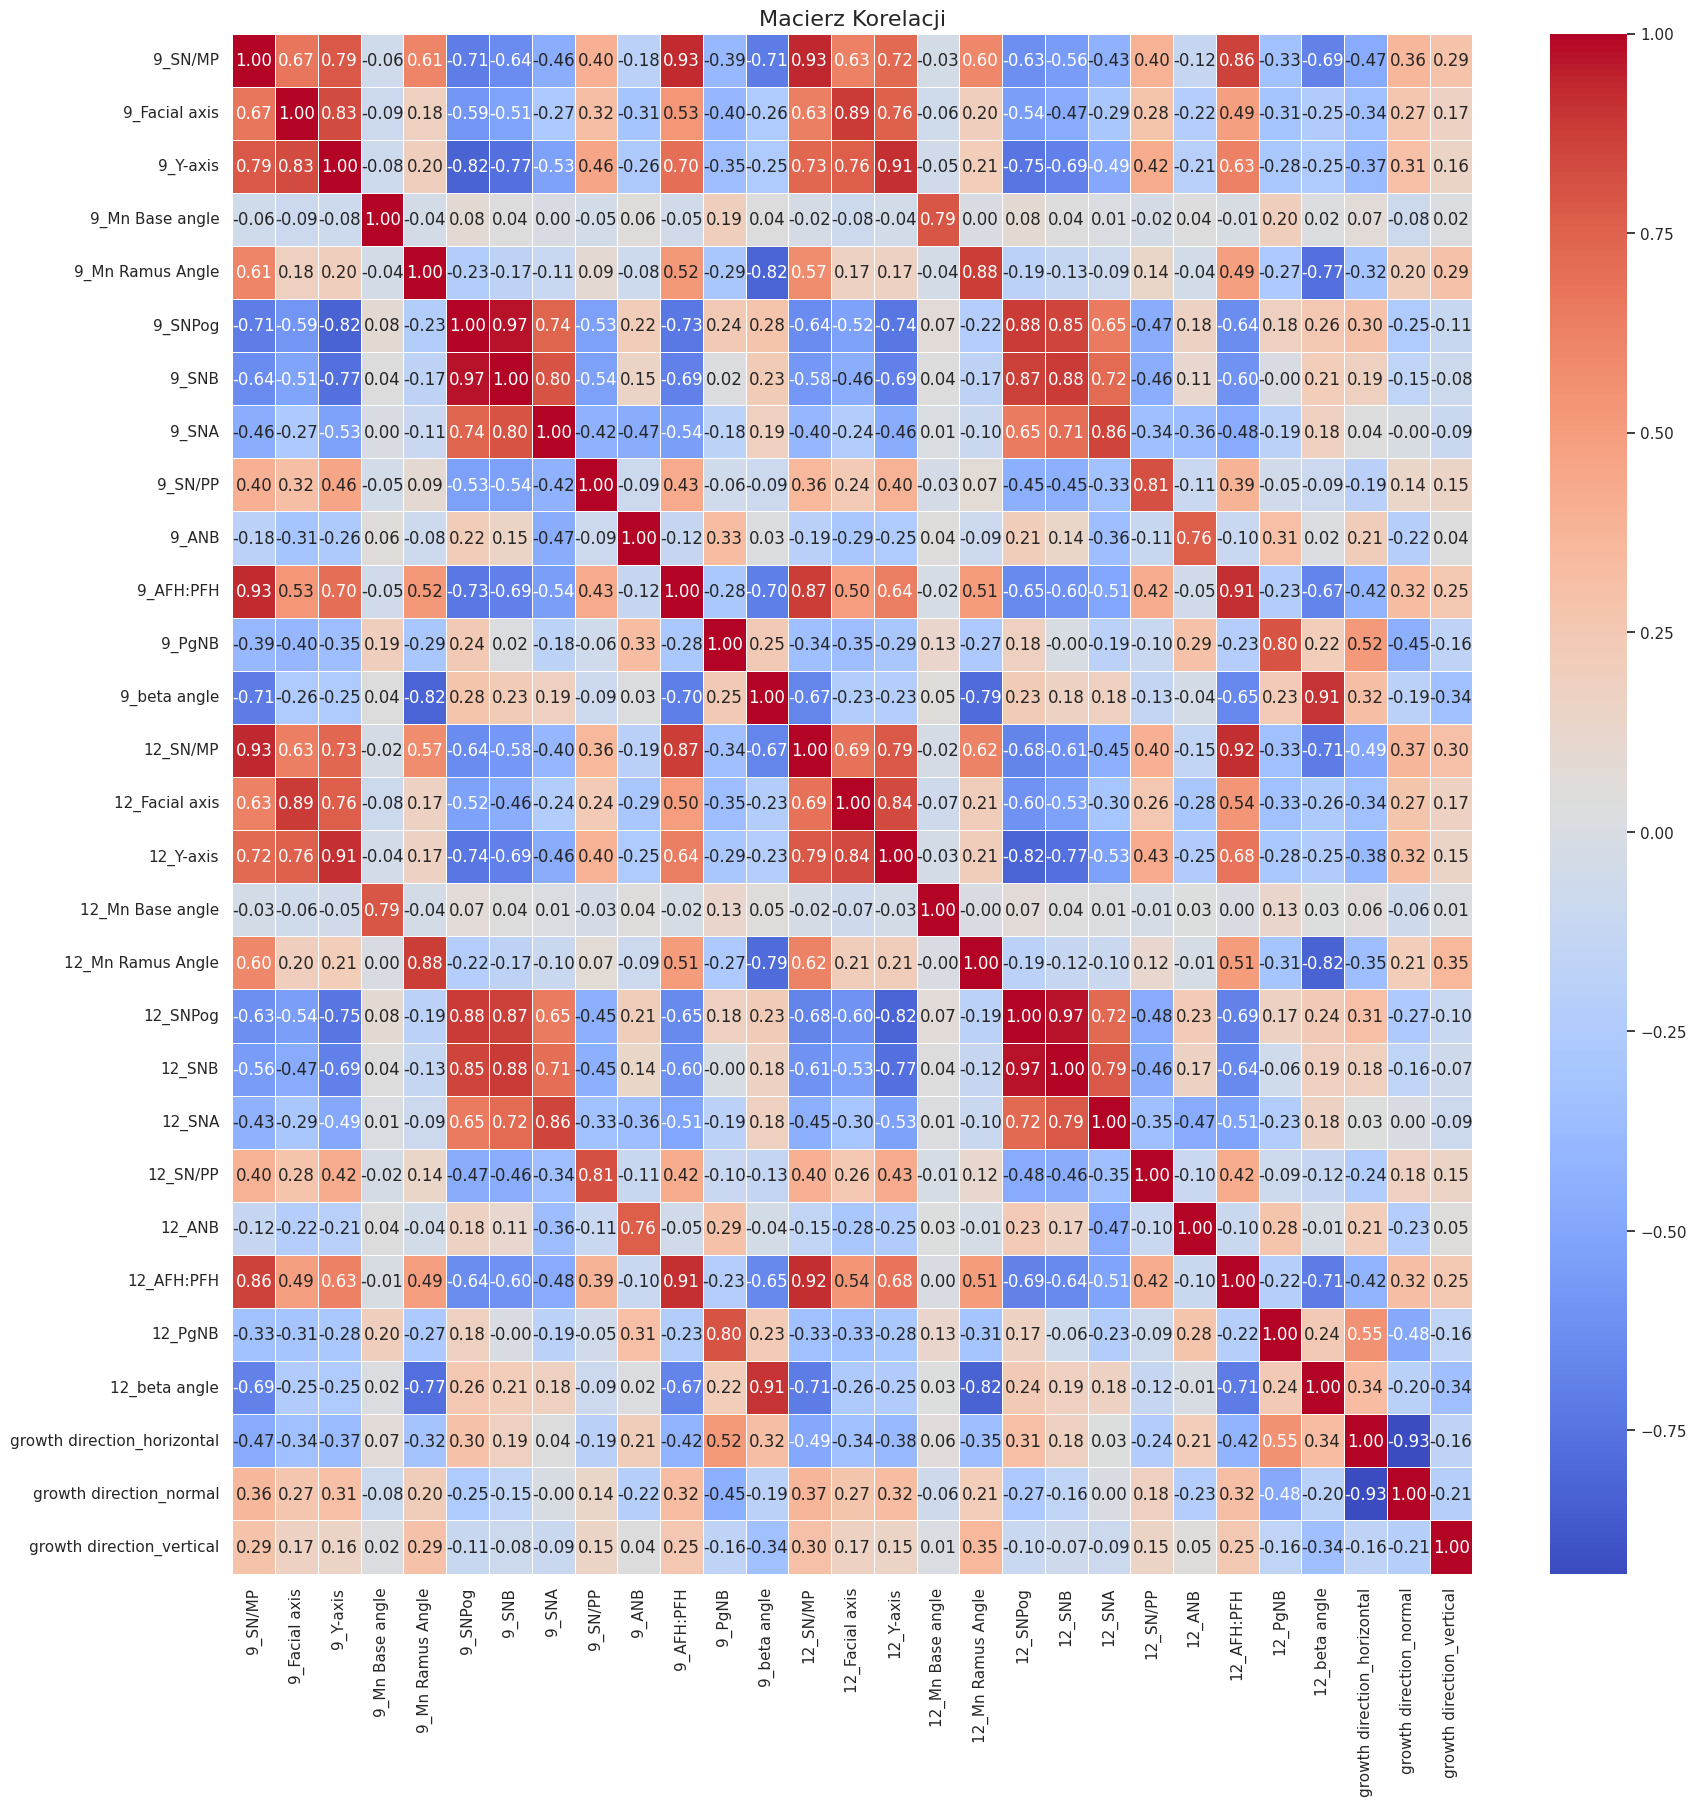

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

print("Seaborn:", sns.__version__)
print("Matplotlib:", matplotlib.__version__)

corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20, 20))

sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title("Macierz Korelacji", fontsize=16)
plt.show()

In [16]:
# Features to delete:
# 9_Y-axis
# 9_Facial axis
# 9_SNPog
# 